Objetivo: usar dataset do kaggle com mascara de segmentação de células para treinar a U-Net

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from PIL import Image
import torch
from torch.utils.data import Dataset
from torchvision import transforms
import glob
import cv2

In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("prahladmehandiratta/cervical-cancer-largest-dataset-sipakmed")

print("Path to dataset files:", path)

/mnt/storage_C1/bianca_zavadisk/SIPaKMeD-gradcam/env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 6.40G/6.40G [03:24<00:00, 33.7MB/s]  

Extracting files...


Path to dataset files: /home/al.bianca.abreu/.cache/kagglehub/datasets/prahladmehandiratta/cervical-cancer-largest-dataset-sipakmed/versions/1


In [5]:
for root, dirs, files in os.walk(path):
    print(root, "→", len(files), "arquivos")

/home/al.bianca.abreu/.cache/kagglehub/datasets/prahladmehandiratta/cervical-cancer-largest-dataset-sipakmed/versions/1 → 0 arquivos
/home/al.bianca.abreu/.cache/kagglehub/datasets/prahladmehandiratta/cervical-cancer-largest-dataset-sipakmed/versions/1/im_Koilocytotic → 0 arquivos
/home/al.bianca.abreu/.cache/kagglehub/datasets/prahladmehandiratta/cervical-cancer-largest-dataset-sipakmed/versions/1/im_Koilocytotic/im_Koilocytotic → 1888 arquivos
/home/al.bianca.abreu/.cache/kagglehub/datasets/prahladmehandiratta/cervical-cancer-largest-dataset-sipakmed/versions/1/im_Koilocytotic/im_Koilocytotic/CROPPED → 2475 arquivos
/home/al.bianca.abreu/.cache/kagglehub/datasets/prahladmehandiratta/cervical-cancer-largest-dataset-sipakmed/versions/1/im_Superficial-Intermediate → 0 arquivos
/home/al.bianca.abreu/.cache/kagglehub/datasets/prahladmehandiratta/cervical-cancer-largest-dataset-sipakmed/versions/1/im_Superficial-Intermediate/im_Superficial-Intermediate → 1788 arquivos
/home/al.bianca.abreu

In [6]:
classes = []

for file in os.listdir(path):
    classes.append(file)

classes

['im_Koilocytotic',
 'im_Superficial-Intermediate',
 'im_Dyskeratotic',
 'im_Parabasal',
 'im_Metaplastic']

In [7]:
base_paths = {
    "Parabasal": "/home/al.bianca.abreu/.cache/kagglehub/datasets/prahladmehandiratta/cervical-cancer-largest-dataset-sipakmed/versions/1/im_Parabasal/im_Parabasal/CROPPED",
    "Metaplastic": "/home/al.bianca.abreu/.cache/kagglehub/datasets/prahladmehandiratta/cervical-cancer-largest-dataset-sipakmed/versions/1/im_Metaplastic/im_Metaplastic/CROPPED",
    "Koilocytotic": "/home/al.bianca.abreu/.cache/kagglehub/datasets/prahladmehandiratta/cervical-cancer-largest-dataset-sipakmed/versions/1/im_Koilocytotic/im_Koilocytotic/CROPPED",
    "Superficial-Intermediate": "/home/al.bianca.abreu/.cache/kagglehub/datasets/prahladmehandiratta/cervical-cancer-largest-dataset-sipakmed/versions/1/im_Superficial-Intermediate/im_Superficial-Intermediate/CROPPED",
    "Dyskeratotic": "/home/al.bianca.abreu/.cache/kagglehub/datasets/prahladmehandiratta/cervical-cancer-largest-dataset-sipakmed/versions/1/im_Dyskeratotic/im_Dyskeratotic/CROPPED"
}

In [8]:
parabasal_path = os.path.join(path, classes[1]) # Metaplastic

# Caminho da subpasta interna
subfolder = os.path.join(parabasal_path, os.listdir(parabasal_path)[0])

# Lista apenas arquivos de imagem
img_files = [os.path.join(subfolder, f) for f in os.listdir(subfolder) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp'))]


In [9]:
parabasal_cropped = base_paths['Parabasal']

# listar arquivos:
img_files = [os.path.join(parabasal_cropped, f) for f in os.listdir(parabasal_cropped) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp'))]

In [10]:
classes = []

for file in os.listdir(path):
    classes.append(file)

classes

['im_Koilocytotic',
 'im_Superficial-Intermediate',
 'im_Dyskeratotic',
 'im_Parabasal',
 'im_Metaplastic']

-> Usar as imagens em cropped

-> Usar as fronteiras (.dat) para criar a mascara separada para o núcleo e o citoplasma

-> Fazer máscara com multicanais

-> Criar uma função que dado os dados ela retorna a mascara da imagem com labels

tentando usar os arquivos .dat para gerar as máscaras:

In [11]:
import os
import glob

def get_samples(class_path):
    bmp_files = sorted(glob.glob(os.path.join(class_path, "*.bmp")))
    samples = []

    for bmp in bmp_files:
        name = os.path.splitext(os.path.basename(bmp))[0]
        cyt_path = os.path.join(class_path, f"{name}_cyt.dat")
        nuc_path = os.path.join(class_path, f"{name}_nuc.dat")
        if os.path.exists(cyt_path) and os.path.exists(nuc_path):
            samples.append({
                "bmp": bmp,
                "cyt": cyt_path,
                "nuc": nuc_path,
                "img_array": bmp
            })
    return samples

In [13]:
all_data[0]

{'bmp': '/home/al.bianca.abreu/.cache/kagglehub/datasets/prahladmehandiratta/cervical-cancer-largest-dataset-sipakmed/versions/1/im_Parabasal/im_Parabasal/CROPPED/001_01.bmp',
 'cyt': '/home/al.bianca.abreu/.cache/kagglehub/datasets/prahladmehandiratta/cervical-cancer-largest-dataset-sipakmed/versions/1/im_Parabasal/im_Parabasal/CROPPED/001_01_cyt.dat',
 'nuc': '/home/al.bianca.abreu/.cache/kagglehub/datasets/prahladmehandiratta/cervical-cancer-largest-dataset-sipakmed/versions/1/im_Parabasal/im_Parabasal/CROPPED/001_01_nuc.dat',
 'img_array': '/home/al.bianca.abreu/.cache/kagglehub/datasets/prahladmehandiratta/cervical-cancer-largest-dataset-sipakmed/versions/1/im_Parabasal/im_Parabasal/CROPPED/001_01.bmp',
 'class': 'Parabasal'}

As amostras estão em all_data em que all_data[index]['bmp']

In [14]:
# Função para ler coordenadas de um .dat
def read_dat_file(dat_path):
    """
    Lê arquivo .dat contendo coordenadas (x,y) do contorno
    e retorna lista de tuplas [(x1,y1), ...]
    """
    coords = []
    with open(dat_path, 'r') as f:
        for line in f:
            line = line.strip()
            if line == "" or line.startswith("#"):
                continue
            parts = line.split(',')
            if len(parts) == 2:
                x, y = map(float, parts)
                coords.append((int(x), int(y)))
    return coords

# Função para gerar máscara multi-canal
def generate_mask_from_contours(height, width, nucleus_coords, cytoplasm_coords):
    """
    Cria máscara binária multi-canal (núcleo e citoplasma) a partir de contornos.
    """
    # Inicializa máscaras
    nucleus_mask = np.zeros((height, width), dtype=np.uint8)
    cytoplasm_mask = np.zeros((height, width), dtype=np.uint8)

    # Converte para int32
    nucleus_poly = np.array(nucleus_coords, dtype=np.int32)
    cytoplasm_poly = np.array(cytoplasm_coords, dtype=np.int32)

    # Preenche os polígonos
    cv2.fillPoly(nucleus_mask, [nucleus_poly], 1)
    cv2.fillPoly(cytoplasm_mask, [cytoplasm_poly], 1)

    # Remove sobreposição do núcleo
    cytoplasm_mask = cytoplasm_mask - nucleus_mask
    cytoplasm_mask[cytoplasm_mask < 0] = 0

    # Empilha canais
    mask = np.stack([nucleus_mask, cytoplasm_mask], axis=0)

    return mask

# Função adaptada para organizar samples
def get_samples(class_path):
    bmp_files = sorted(glob.glob(os.path.join(class_path, "*.bmp")))
    samples = []

    for bmp in bmp_files:
        name = os.path.splitext(os.path.basename(bmp))[0]
        cyt_path = os.path.join(class_path, f"{name}_cyt.dat")
        nuc_path = os.path.join(class_path, f"{name}_nuc.dat")
        if os.path.exists(cyt_path) and os.path.exists(nuc_path):
            # Lê tamanho da imagem
            img = Image.open(bmp)
            width, height = img.size

            # Lê coordenadas e gera máscara
            nucleus_coords = read_dat_file(nuc_path)
            cytoplasm_coords = read_dat_file(cyt_path)
            mask = generate_mask_from_contours(height, width, nucleus_coords, cytoplasm_coords)

            samples.append({
                "bmp": bmp,
                "cyt": cyt_path,
                "nuc": nuc_path,
                "img_array": np.array(img),
                "mask": mask
            })
    return samples

# Montar all_data com todas as classes
all_data = []
for cls, path in base_paths.items():
    samples = get_samples(path)
    for s in samples:
        s["class"] = cls
    all_data.extend(samples)

print(f"Total de amostras processadas: {len(all_data)}")


Total de amostras processadas: 4049


Visualizando mascaras:

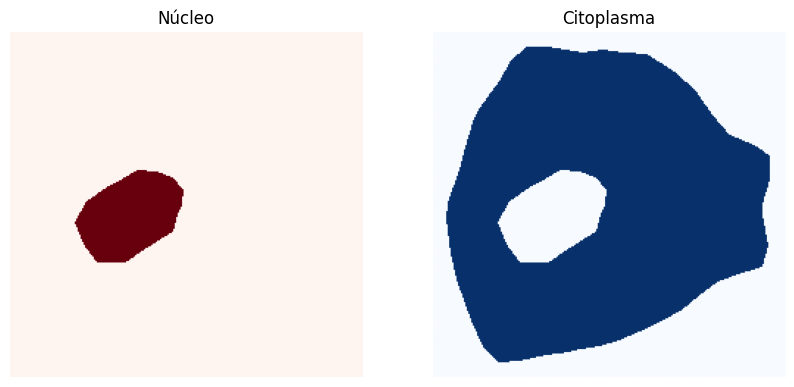

In [15]:
# Suponha que você tenha uma amostra do all_data
sample = all_data[1]
mask = sample['mask']  # shape: (2, H, W)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(mask[0], cmap='Reds')  # Núcleo
plt.title("Núcleo")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mask[1], cmap='Blues')  # Citoplasma
plt.title("Citoplasma")
plt.axis("off")

plt.show()


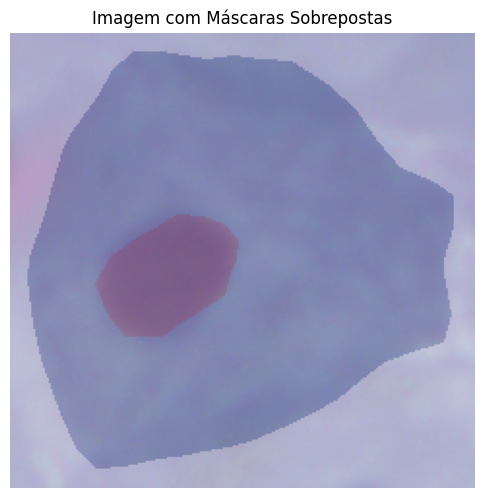

In [16]:
img = sample['img_array']

plt.figure(figsize=(6,6))
plt.imshow(img, cmap='gray')  # imagem original

# Sobreposição núcleo em vermelho (transparência alpha=0.5)
plt.imshow(mask[0], cmap='Reds', alpha=0.3)

# Sobreposição citoplasma em azul (transparência alpha=0.3)
plt.imshow(mask[1], cmap='Blues', alpha=0.2)

plt.axis("off")
plt.title("Imagem com Máscaras Sobrepostas")
plt.show()


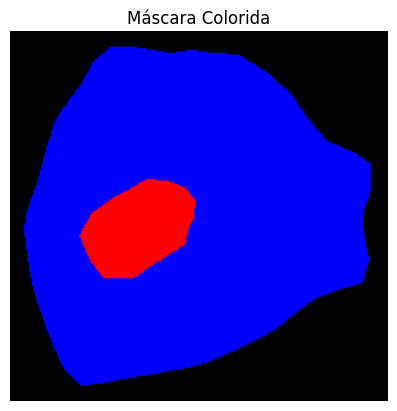

In [17]:
import numpy as np

# Criar imagem RGB vazia
H, W = mask.shape[1], mask.shape[2]
color_mask = np.zeros((H, W, 3), dtype=np.uint8)

# Núcleo vermelho
color_mask[mask[0] > 0] = [255, 0, 0]

# Citoplasma azul (pixels que não são núcleo)
color_mask[(mask[1] > 0) & (mask[0] == 0)] = [0, 0, 255]

plt.imshow(color_mask)
plt.axis("off")
plt.title("Máscara Colorida")
plt.show()


### Split dos dados

In [20]:
import random
from collections import defaultdict

# Define uma semente para que o sorteio seja sempre o mesmo ao reexecutar
random.seed(42)

# Agrupa os dicionários de crops por lâmina (slide) dentro de cada classe
slides_por_classe = defaultdict(lambda: defaultdict(list))

for sample in all_data:
    filename = os.path.basename(sample["bmp"])     # Pega ex: "001_01.bmp"
    slide_id = filename.split('_')[0]               # Isola o slide original: "001"
    cls = sample["class"]                           # Classe da célula
    
    slides_por_classe[cls][slide_id].append(sample)

# Realiza a separação separando lâminas inteiras
train_data = []
test_data = [] 
train_ratio = 0.8  # 80% para treino, 20% para teste

for cls, slides_dict in slides_por_classe.items():
    lista_slides = list(slides_dict.keys())
    random.shuffle(lista_slides) # Sorteia as lâminas
    
    split_idx = int(len(lista_slides) * train_ratio)
    train_slides_ids = lista_slides[:split_idx]
    test_slides_ids = lista_slides[split_idx:]
    
    # Coleta todos os crops pertencentes às lâminas sorteadas
    for slide_id in train_slides_ids:
        train_data.extend(slides_dict[slide_id])
        
    for slide_id in test_slides_ids:
        test_data.extend(slides_dict[slide_id])

print(f"Amostras destinadas ao Treino: {len(train_data)} crops")
print(f"Amostras destinadas ao Teste/Validação: {len(test_data)} crops")

Amostras destinadas ao Treino: 3220 crops
Amostras destinadas ao Teste/Validação: 829 crops


### Aplicando os dados na U-Net

In [21]:
def resize_mask(mask, size=(192,192)):
    """
    mask: numpy array (C,H,W)
    size: (height, width)
    """
    C, H, W = mask.shape
    resized = np.zeros((C, size[0], size[1]), dtype=mask.dtype)
    for c in range(C):
        resized[c] = cv2.resize(mask[c], (size[1], size[0]), interpolation=cv2.INTER_NEAREST)
    return resized

In [22]:
class CellDataset(Dataset):
    def __init__(self, data_list, transform=None, mask_size=(192,192)):
        """
        data_list: lista com dicionários do tipo all_data
        transform: transformações para as imagens
        """
        self.data_list = data_list
        self.transform = transform
        self.mask_size = mask_size

    def __len__(self):
        return len(self.data_list)

    def __getitem__(self, idx):
        sample = self.data_list[idx]
        img = Image.open(sample['bmp']).convert("RGB")
        if self.transform:
            img = self.transform(img)
        else:
            img = transforms.ToTensor()(img)

        mask = resize_mask(sample['mask'], size=self.mask_size)
        mask = torch.from_numpy(mask).float()

        return img, mask


In [24]:
from torch.utils.data import DataLoader

# Transformações para a imagem (Tensor + Normalização)
transform = transforms.Compose([
    transforms.Resize((192, 192)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])  # ImageNet
])

train_dataset = CellDataset(train_data, transform=transform)
test_dataset = CellDataset(test_data, transform=transform)

train_dataloader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=8, shuffle=False)

In [32]:
from collections import defaultdict
from UNet_model import UNet, calc_loss
from tqdm import tqdm

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = UNet(n_class=2).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.1)

num_epochs = 10
for epoch in range(num_epochs):
    # ================= TREINO =================
    model.train()
    running_train_loss = 0.0  
    
    # Cria a barra de progresso para o treino desta época
    train_bar = tqdm(train_dataloader, desc=f"Epoch {epoch+1:02d}/{num_epochs} [Treino]", leave=False)

    for imgs, masks in train_bar:
        imgs = imgs.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)  
        loss = calc_loss(outputs, masks, metrics=defaultdict(float))  
        loss.backward()
        optimizer.step()
        
        running_train_loss += loss.item()
        
        # Mostra o loss do batch atual diretamente na barra de progresso
        train_bar.set_postfix(loss=f"{loss.item():.4f}")
    
    scheduler.step()
    epoch_train_loss = running_train_loss / len(train_dataloader)

    # ================= VALIDAÇÃO =================
    model.eval()
    running_val_loss = 0.0
    
    # Cria a barra de progresso para a validação (leave=False faz sumir ao terminar para não poluir o ecrã)
    val_bar = tqdm(test_dataloader, desc=f"Epoch {epoch+1:02d}/{num_epochs} [Val]", leave=False)
    
    with torch.no_grad():
        for val_imgs, val_masks in val_bar:
            val_imgs = val_imgs.to(device)
            val_masks = val_masks.to(device)
            
            val_outputs = model(val_imgs)
            v_loss = calc_loss(val_outputs, val_masks, metrics=defaultdict(float))
            running_val_loss += v_loss.item()
            
            # Mostra o loss de validação do batch atual na barra
            val_bar.set_postfix(loss=f"{v_loss.item():.4f}")
            
    epoch_val_loss = running_val_loss / len(test_dataloader)

    # Print final estático de resumo da época
    print(f"✨ Epoch {epoch+1:02d}/{num_epochs} -> Train Loss Médio: {epoch_train_loss:.4f} | Val Loss Médio: {epoch_val_loss:.4f}")

✨ Epoch 01/10 -> Train Loss Médio: 0.3810 | Val Loss Médio: 0.2056


✨ Epoch 02/10 -> Train Loss Médio: 0.2251 | Val Loss Médio: 0.1704


✨ Epoch 03/10 -> Train Loss Médio: 0.1949 | Val Loss Médio: 0.1626


✨ Epoch 04/10 -> Train Loss Médio: 0.1736 | Val Loss Médio: 0.1759


✨ Epoch 05/10 -> Train Loss Médio: 0.1628 | Val Loss Médio: 0.1546


✨ Epoch 06/10 -> Train Loss Médio: 0.1493 | Val Loss Médio: 0.1462


✨ Epoch 07/10 -> Train Loss Médio: 0.1409 | Val Loss Médio: 0.1314


✨ Epoch 08/10 -> Train Loss Médio: 0.1301 | Val Loss Médio: 0.1417


✨ Epoch 09/10 -> Train Loss Médio: 0.1373 | Val Loss Médio: 0.1301


✨ Epoch 10/10 -> Train Loss Médio: -0.0891 | Val Loss Médio: 0.1524


In [33]:
# Save model pth
torch.save(model.state_dict(), "unet_model.pth")

In [34]:
def masks_to_coloring(masks):
    n_classes = masks.shape[0]
    colors = np.array([
        (201, 58, 64),
        (242, 207, 1),
        (0, 152, 75),
        (101, 172, 228),
        (56, 34, 132),
        (160, 194, 56)
    ][:n_classes])  # pega apenas as cores necessárias

    colorimg = np.ones((masks.shape[1], masks.shape[2], 3), dtype=np.float32) * 255
    channels, height, width = masks.shape

    for y in range(height):
        for x in range(width):
            selected_colors = colors[masks[:,y,x] > 0.5]
            if len(selected_colors) > 0:
                colorimg[y,x,:] = np.mean(selected_colors, axis=0)

    return colorimg.astype(np.uint8)


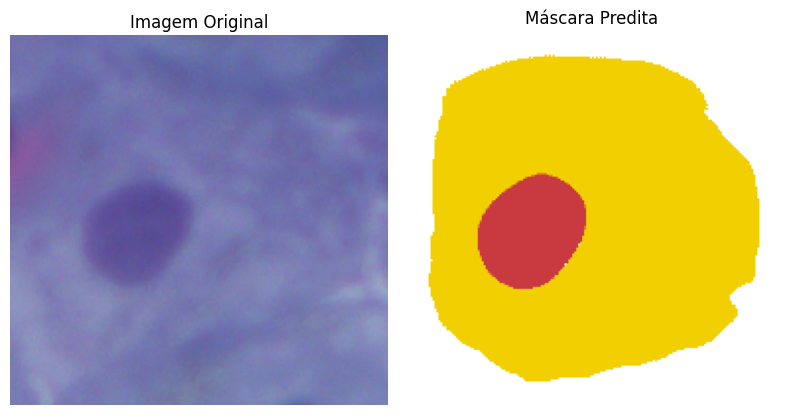

In [35]:
img_cell = Image.open(all_data[1]['bmp']).convert("RGB")

transform = transforms.Compose([
    transforms.Resize((192, 192)),  # ou o tamanho usado no treino
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

img_tensor = transform(img_cell).unsqueeze(0)  # adiciona dimensão batch

img_tensor = img_tensor.to(device)

model.eval()
with torch.no_grad():
    pred = model(img_tensor)
    pred = torch.sigmoid(pred)
    pred = pred.cpu().numpy()[0]  # shape: (C, H, W)

pred_color = masks_to_coloring(pred)

plt.figure(figsize=(8, 6))  # largura maior para caber duas imagens

# Imagem original
plt.subplot(1, 2, 1)
plt.imshow(img_cell, cmap='gray')
plt.axis("off")
plt.title("Imagem Original")

# Máscara predita colorida
plt.subplot(1, 2, 2)
plt.imshow(pred_color)
plt.axis("off")
plt.title("Máscara Predita")

plt.tight_layout()
plt.show()


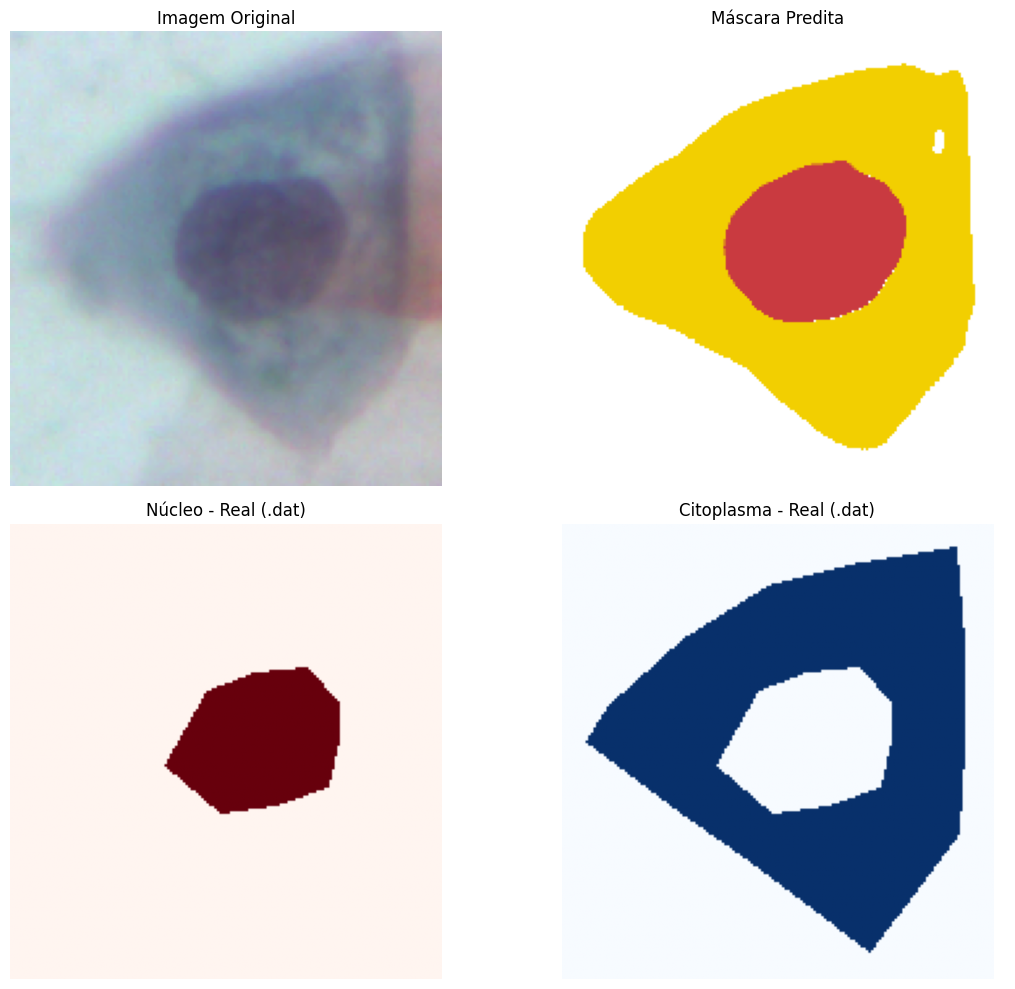

In [36]:
import matplotlib.pyplot as plt

sample_index = 2000

img_cell = Image.open(all_data[sample_index]['bmp']).convert("RGB")

# Transformações
transform = transforms.Compose([
    transforms.Resize((192, 192)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

img_tensor = transform(img_cell).unsqueeze(0).to(device)

# Inferência
model.eval()
with torch.no_grad():
    pred = model(img_tensor)
    pred = torch.sigmoid(pred)
    pred = pred.cpu().numpy()[0]  # shape: (C, H, W)

pred_color = masks_to_coloring(pred)
mask = all_data[sample_index]['mask']  # shape: (2, H, W)

# Plot 2x2
plt.figure(figsize=(12, 10))

plt.subplot(2, 2, 1)
plt.imshow(img_cell)
plt.axis("off")
plt.title("Imagem Original")

plt.subplot(2, 2, 2)
plt.imshow(pred_color)
plt.axis("off")
plt.title("Máscara Predita")

plt.subplot(2, 2, 3)
plt.imshow(mask[0], cmap='Reds')
plt.axis("off")
plt.title("Núcleo - Real (.dat)")

plt.subplot(2, 2, 4)
plt.imshow(mask[1], cmap='Blues')
plt.axis("off")
plt.title("Citoplasma - Real (.dat)")

plt.tight_layout()
plt.show()
